인간 평가자가 독성 행동으로 분류한 많은 수의 Wikipedia 댓글이 제공됩니다. 독성의 종류는 다음과 같습니다.

toxic

severe_toxic

obscene

threat

insult

identity_hate


각 의견에 대한 각 유형의 독성 확률을 예측하는 모델을 만들어야 합니다.

In [6]:
import sys, os, re, csv, codecs, numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from keras.layers import Bidirectional, GlobalMaxPool1D
from keras.models import Model
from keras import initializers, regularizers, constraints, optimizers, layers

In [2]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

In [3]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
train.isnull().any(),test.isnull().any()

(id               False
 comment_text     False
 toxic            False
 severe_toxic     False
 obscene          False
 threat           False
 insult           False
 identity_hate    False
 dtype: bool,
 id              False
 comment_text    False
 dtype: bool)

처리해야할 null값 존재하지 않음

In [7]:
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values
list_sentences_train = train["comment_text"]
list_sentences_test = test["comment_text"]

댓글 내용과 독성 종류를 나눈 데이터셋을 생성

댓글 내용을 그대로 LSTM에 입력하는 것은 불가능하므로 "토큰화", "색인화"를 시켜야한다.

예를 들어 I love cats and dogs. 문장은 다음과 같이 변해야한다.

["I","love","cats","and","dogs"]

이후 다음과 같이 바꾸어야 한다.

{1:"I", 2:"love", 3:"cats", 4:", 5:"dogs"}

</br>

그러나 케라스에서는 이 과정을 간단하게 제공해준다.

In [8]:
max_features = 20000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(list_sentences_train))
list_tokenized_train = tokenizer.texts_to_sequences(list_sentences_train)
list_tokenized_test = tokenizer.texts_to_sequences(list_sentences_test)

토큰화 된 데이터셋을 보면 인덱스화가 되어있는 것을 확인할 수 있다.

In [9]:
list_tokenized_train[:1]

[[688,
  75,
  1,
  126,
  130,
  177,
  29,
  672,
  4511,
  12052,
  1116,
  86,
  331,
  51,
  2278,
  11448,
  50,
  6864,
  15,
  60,
  2756,
  148,
  7,
  2937,
  34,
  117,
  1221,
  15190,
  2825,
  4,
  45,
  59,
  244,
  1,
  365,
  31,
  1,
  38,
  27,
  143,
  73,
  3462,
  89,
  3085,
  4583,
  2273,
  985]]

In [10]:
maxlen = 200
X_t = pad_sequences(list_tokenized_train, maxlen=maxlen)
X_te = pad_sequences(list_tokenized_test, maxlen=maxlen)

댓글들의 길이가 모두 차이나기 때문에 이를 맞추고자 최대길이를 200으로 설정하고 짧은 댓글은 0으로 채운다.

In [11]:
totalNumWords = [len(one_comment) for one_comment in list_tokenized_train]

최대길이를 적절하게 설정하기 위해 문장의 단어 수 분포를 본다.

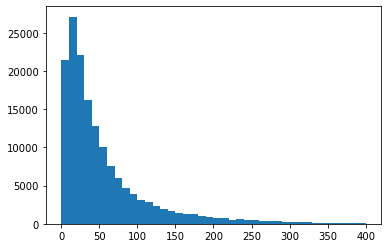

In [12]:
plt.hist(totalNumWords,bins = np.arange(0,410,10))#[0,50,100,150,200,250,300,350,400])#,450,500,550,600,650,700,750,800,850,900])
plt.show()

대부분의 문장 길이는 30개 정도이기 때문에 50으로 최대길이를 설정해도 되지만 이 코드에서는 200으로 설정하였다.

In [13]:
inp = Input(shape=(maxlen, )) #maxlen=200 as defined earlier

In [14]:
embed_size = 128
x = Embedding(max_features, embed_size)(inp)

In [15]:
x = LSTM(60, return_sequences=True,name='lstm_layer')(x)

In [16]:
x = GlobalMaxPool1D()(x)

In [17]:
x = Dropout(0.1)(x)

In [18]:
x = Dense(50, activation="relu")(x)

In [19]:
x = Dropout(0.1)(x)

In [20]:
x = Dense(6, activation="sigmoid")(x)

In [21]:
model = Model(inputs=inp, outputs=x)
model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [22]:
batch_size = 32
epochs = 2
model.fit(X_t,y, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/2
4488/4488 [==============================] - 807s 178ms/step - loss: 0.0687 - accuracy: 0.9610 - val_loss: 0.0494 - val_accuracy: 0.9940
Epoch 2/2
4488/4488 [==============================] - 781s 174ms/step - loss: 0.0452 - accuracy: 0.9835 - val_loss: 0.0462 - val_accuracy: 0.9918


In [23]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200)]             0         
                                                                 
 embedding (Embedding)       (None, 200, 128)          2560000   
                                                                 
 lstm_layer (LSTM)           (None, 200, 60)           45360     
                                                                 
 global_max_pooling1d (Globa  (None, 60)               0         
 lMaxPooling1D)                                                  
                                                                 
 dropout (Dropout)           (None, 60)                0         
                                                                 
 dense (Dense)               (None, 50)                3050      
                                                             

In [24]:
from keras import backend as K

# with a Sequential model
get_3rd_layer_output = K.function([model.layers[0].input],
                                  [model.layers[2].output])
layer_output = get_3rd_layer_output([X_t[:1]])[0]
layer_output.shape
#print layer_output to see the actual data

(1, 200, 60)

출력이 예상대로 실행되는지 보기 위해 특정 레이어의 출력을 표시해보면 위와 같다.